# ASTR 223 Final Project: Gaussian Process Model (xHRs)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## modeling libraries
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

blue_color = '#005A9C'
red_color = '#EF3E42'
color_palette = {0: blue_color, 1: red_color}

In [ ]:
batted_ball_events = pd.read_parquet('data/batted_ball_events.parquet')
player_primary_pos = pd.read_parquet('data/player_primary_pos.parquet')

In [9]:
X = np.array(batted_ball_events[['launch_speed', 'launch_angle']])
y = np.array(batted_ball_events['is_HR'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

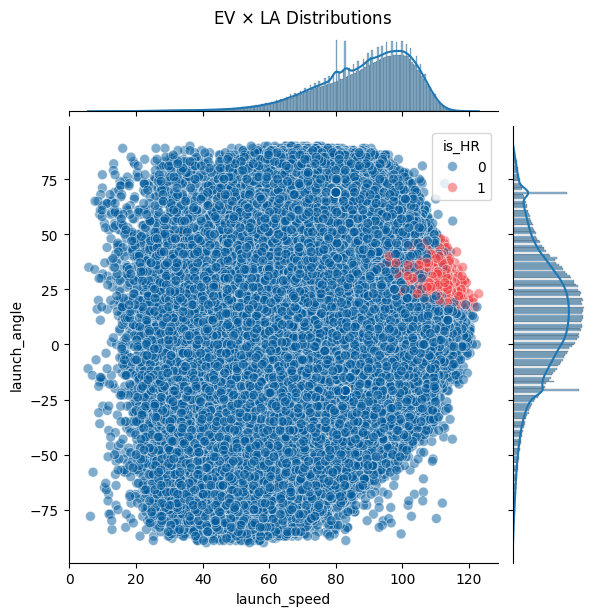

In [12]:
X_train_df = pd.DataFrame(X_train, columns=["launch_speed", "launch_angle"])
X_train_df["is_HR"] = y_train
joint_grid = sns.JointGrid(data=X_train_df, x="launch_speed", y="launch_angle")
sns.scatterplot(data=X_train_df, x="launch_speed", y="launch_angle", hue="is_HR", palette=color_palette, alpha=0.5, s=50, ax=joint_grid.ax_joint)
sns.histplot(data=X_train_df, x="launch_speed", kde=True, ax=joint_grid.ax_marg_x)
sns.histplot(data=X_train_df, y="launch_angle", kde=True, ax=joint_grid.ax_marg_y)
joint_grid.ax_joint.legend(title="is_HR", loc="upper right")
plt.suptitle(r"EV $\times$ LA Distributions", y=1.02)
plt.show()

In [16]:
## standardizing the continous features --> ensures numerical stability
scaler_pipeline = make_pipeline(StandardScaler())
X_train_scaled = scaler_pipeline.fit_transform(X_train)
## standardizing test too based on the means, stds computed from the training set
X_test_scaled = scaler_pipeline.fit_transform(X_test)